# Pipeline

- BANDPASS -> CSP -> LDA

- Mean Accuracy: 58.3 %

# Load the Data

In [29]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_csp"]
y = data["y"]

# Dropping Channels

In [30]:
# C3 -> 3
# Cz -> 4 
# C4 -> 5
BAD_CHANNELS = [0,1,2,6,7]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)

(100, 3, 750)


# Preliminary Filtering

In [31]:
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

FS = 250

for trial in range(X.shape[0]):
    for ch in range(X.shape[1]):

        DataFilter.detrend(
            X[trial, ch],
            DetrendOperations.CONSTANT.value
        )

        DataFilter.perform_bandpass(
            X[trial, ch],
            FS,
            8.0,
            13.0,
            4,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

## Plot Pre CSP

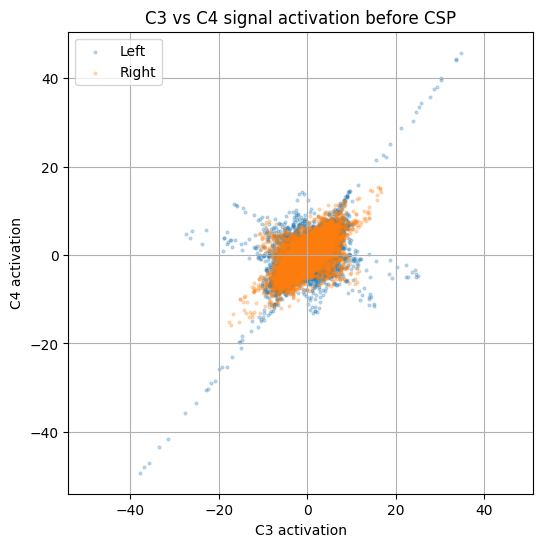

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# X shape: (trials, channels, samples)
# y shape: (trials,) labels, e.g. 0 = left, 1 = right

C3_IDX = 0   
C4_IDX = 2   

LEFT = 1
RIGHT = 2

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation before CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# CSP Activation

In [33]:
import numpy as np
from brainflow.data_filter import DataFilter

LEFT = 1
RIGHT = 2

y_csp = np.zeros_like(y, dtype=np.float64)
y_csp[y == RIGHT] = 1.0

mask = (y == LEFT) | (y == RIGHT)

X_bf = np.ascontiguousarray(X[mask], dtype=np.float64)
y_bf = np.ascontiguousarray(y_csp[mask], dtype=np.float64)
filters, eigenvalues = DataFilter.get_csp(X_bf, y_bf)

X_csp_signal = np.array([
    filters @ trial
    for trial in X_bf
])

print("X_csp_signal:", X_csp_signal.shape)

X = X_csp_signal
y = y_bf

X_csp_signal: (100, 3, 750)


# Post CSP Plot

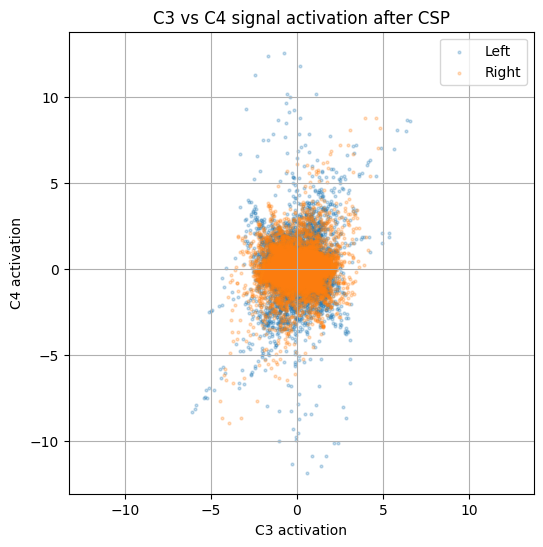

In [34]:
import numpy as np
import matplotlib.pyplot as plt

C3_IDX = 0   
C4_IDX = 2   

LEFT = 0
RIGHT = 1

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation after CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# LDA

In [ ]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

# 1) CSP log-variance features
var = np.var(X, axis=2)          # (trials, components)
features = np.log(var + 1e-12)   # avoid log(0)

print("Feature shape:", features.shape)
print("Labels:", np.unique(y, return_counts=True))

# 2) LDA
lda = LinearDiscriminantAnalysis(
    solver="eigen",
    shrinkage="auto"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lda,
    features,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

lda.fit(features, y)
pred = lda.predict(features)

print("\nConfusion matrix:")
print(confusion_matrix(y, pred))

print("\nClassification report:")
print(classification_report(
    y,
    pred,
    target_names=["Left", "Right"]
))

Feature shape: (100, 3)
Labels: (array([0., 1.]), array([50, 50]))
CV scores: [0.5  0.55 0.6  0.45 0.6 ]
Mean accuracy: 0.54
Std: 0.058309518948452994

Confusion matrix:
[[26 24]
 [22 28]]

Classification report:
              precision    recall  f1-score   support

        Left       0.54      0.52      0.53        50
       Right       0.54      0.56      0.55        50

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.54       100
weighted avg       0.54      0.54      0.54       100

